In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from matplotlib import patches as pat
from matplotlib import transforms
from matplotlib.collections import PatchCollection
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from joblib import load, dump
import re
import scipy.cluster.hierarchy as sch

# custom code
import figutils
sys.path.insert(
    0, os.path.abspath('../2021_07_31_custom_adjacency_regularization/'))
import sequence_logo
from quad_model import *
import kl
import force

%matplotlib inline

2022-01-02 09:37:59.108375: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64:/.singularity.d/libs
2022-01-02 09:37:59.108396: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
Matplotlib is building the font cache; this may take a moment.


In [3]:
plt.style.use('/home/ms7490/scratch/code/scratch/matplotlib/clean.mplstyle')

# Transformations playground

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


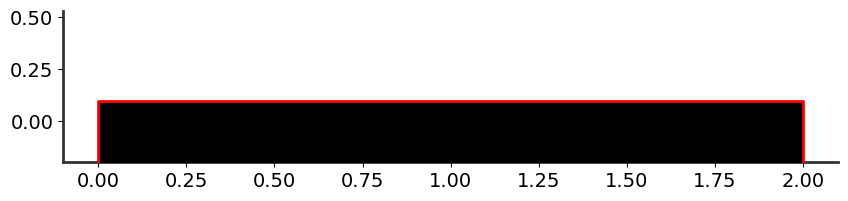

In [4]:
fig, ax = plt.subplots(figsize=(10, 2), dpi=100)

trans = transforms.blended_transform_factory(
    ax.transData, fig.dpi_scale_trans)
ax.add_collection(PatchCollection(
        [
            pat.Rectangle(
                xy=(0, 0),
                width=2,
                height=1,
                fc='k',
                ec='r',
                linewidth=2,
            )
        ],
        zorder=10,
        match_original=True,
        transform=trans
    ))

ax.autoscale_view()

In [5]:
def get_rectangle(xy, width, height, fc='k', ec='r', linewidth=2, transform=None, zorder=0):
    rectangle = PatchCollection(
        [
            pat.Rectangle(
                xy=xy,
                width=width,
                height=height,
                fc=fc,
                ec=ec,
                linewidth=linewidth,
                alpha=0.2
            )
        ],
        zorder=zorder,
        match_original=True,
        transform=transform
    )
    return rectangle

In [7]:
def right_chevron_fn(
        current_x,
        lower_y,
        chevron_height=0.3,
        chevron_width=2/3,
        chevron_angle=30
    ,
    ):
        return pat.Polygon(
            force.get_chevron_coords(
                current_x,
                lower_y,
                height=chevron_height,
                width=chevron_width,
                chevron_angle=chevron_angle,
            ),
            fc="r",
            ec="w",
            alpha=0.15,
            linewidth=0.0,
        )

In [140]:
xmin, xmax = (-60, 100)
ymin, ymax = (-1, 5)

1.8236559139784987
2.184946236559142
Bbox(x0=-1.092473118279571, y0=-0.09536423841059638, x1=1.092473118279571, y1=0.09536423841059571)
Bbox(x0=1231.0, y0=238.83333333333331, x1=1262.75, y1=262.8333333333333)
Bbox(x0=1231.0, y0=238.83333333333331, x1=1262.75, y1=262.8333333333333)
2.184946236559142


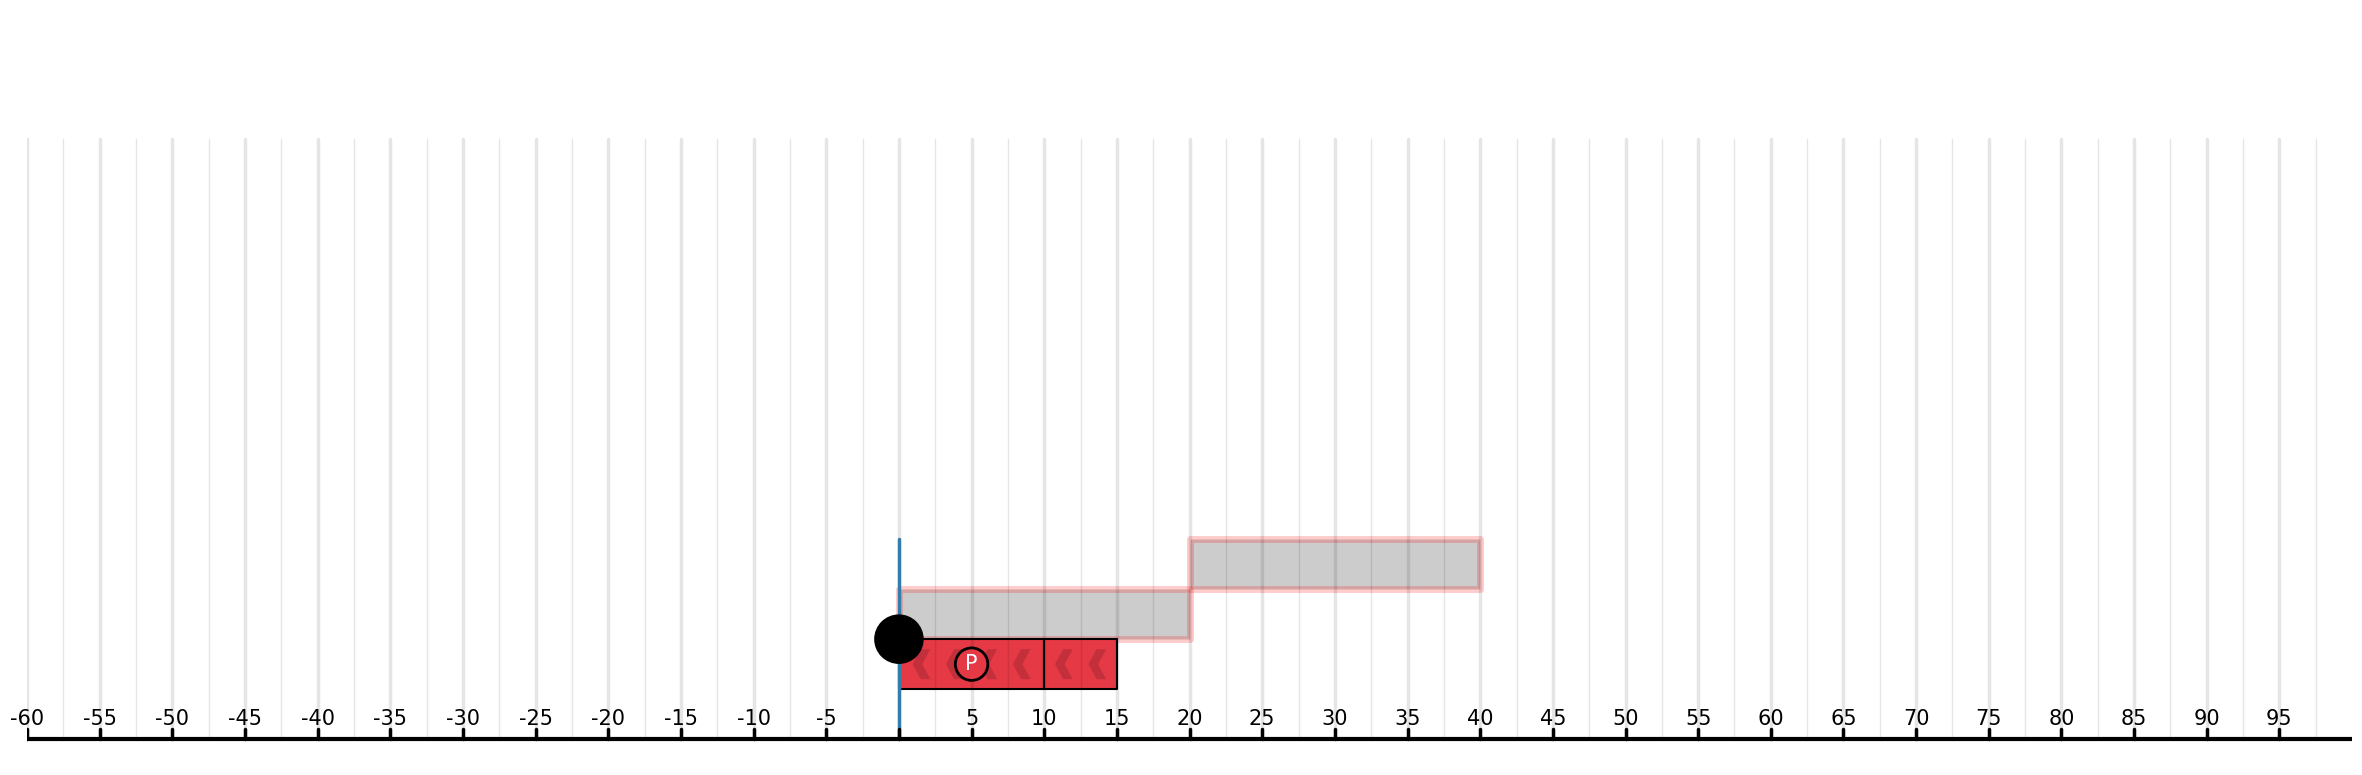

In [144]:
fig, ax = plt.subplots(figsize=(30, 10), dpi=100)
# important: set axes limits first
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

trans = transforms.blended_transform_factory(
    ax.transData, fig.dpi_scale_trans) + transforms.ScaledTranslation(0, 0, scale_trans=transforms.blended_transform_factory(
        fig.dpi_scale_trans, ax.transData))

current_x = 0
for f_i_name, f_i in zip(['s'], [23]):
    # labels = [incl_filter_lookup[e] for e in f_i_name.split('___')]
    # print(labels, f_i)

    break


rect = get_rectangle((0, 0), 20, 0.5, transform=trans, linewidth=5)
ax.add_collection(rect)

rect = get_rectangle((20, .5), 20, 0.5, transform=trans, linewidth=5)
ax.add_collection(rect)

# chevron = right_chevron_fn(0, 0)
# ax.add_collection(PatchCollection(
#         [
#             chevron
#         ],
#         zorder=12,
#         match_original=True,
#         transform=trans
#     ))

# chevrons = PatchCollection(
#         force.center_pattern_in_bbox(
#             0 + 0.5,
#             0.1,
#             20 - 1,
#             0.3,
#             pattern_fn=right_chevron_fn,
#             pattern_spacing=2,
#         ),
#         zorder=1,
#         match_original=True,
#         transform=trans
#     )
# ax.add_collection(chevrons)

force.draw_force(
    ax,
    fig,
    0,
    -0.5,
    10,
    0.5,
    ['P'],
    label_spacing=3,
    label_linewidth=2,
    label_fontsize=15,
    label_textcolor="w",
    chevron_width=2/3,
    chevron_spacing=2,
    chevron_height_fraction=0.6,
    chevron_angle=30,
    ec="#000000",
    linewidth=1.5,
    zorder=1,
    left_color="#e63946",
    right_color="#4895ef",
    direction="left",
    transform=trans
)

force.draw_force(
    ax,
    fig,
    10,
    -0.5,
    5,
    0.5,
    ['A'],
    label_spacing=3,
    label_linewidth=2,
    label_fontsize=18,
    label_textcolor="w",
    chevron_width=2/3,
    chevron_spacing=2,
    chevron_height_fraction=0.6,
    chevron_angle=30,
    ec="#000000",
    linewidth=1.5,
    zorder=1,
    left_color="#e63946",
    right_color="#4895ef",
    direction="left",
    transform=trans
)

# force.draw_axes(ax)

ax.plot([0, 0], [-1, 1], transform=trans)

# # draw PSI axis
# for x, y in zip(xs, ys):
#     # psi ticks
#     ax.plot([x, x], [ymin, ymin - 0.5], color='k')
#     # psi tick annotations
#     if y < 0.9:
#         ax.annotate(np.round(y, decimals=1), (x, ymin - 1.5),
#                     ha='center', va='center')
#     else:
#         ax.annotate(np.round(y, decimals=2), (x, ymin - 1.5),
#                     ha='center', va='center')



text_patch = ax.text(
        0,
        0,
        f"10",
        color="k",
        zorder=0 + 2,
        # transform=ax.transData,
        transform=trans,
        weight="bold",
        fontweight="normal",
        ha="center",
        va="center",
        alpha=0.5,
        fontsize=18,
        bbox={
            "boxstyle": "circle",
            "facecolor": 'k',
            "linewidth": 2,
            "edgecolor": "k",
            "alpha": 1,
        },
    )

print(ax.transData.inverted().transform_bbox(text_patch.get_window_extent(renderer=fig.canvas.get_renderer())))
print(text_patch.get_window_extent(renderer=fig.canvas.get_renderer()))

bbox = text_patch.get_tightbbox(renderer=fig.canvas.get_renderer())
print(bbox)
print(trans.inverted().transform_bbox(bbox).width)
# _, ymax = ax.transData.inverted().transform(trans.transform((0, 1)))
# _, ymin = ax.transData.inverted().transform(trans.transform((0, -1)))

force.draw_axes(ax, xmin, xmax, ymin, ymax, transform=trans, x_tick_interval=5)

# # draw axis labels
# ax.plot([xmin, xmax], [ymin, ymin], color='k', linewidth=3, transform=trans)
# for x in np.arange(xmin, xmax, 10):
#     # delta force ticks
#     ax.plot([x, x], [ymin, ymin + 0.1], color='k', transform=trans)
#     # delta force grid lines
#     ax.plot([x, x], [ymin, ymax], color='k', alpha=0.1, zorder=2, transform=trans)
#     # delta force minor grid lines
#     ax.plot([x + 5, x + 5], [ymin, ymax], color='k', alpha=0.1, zorder=1, linewidth=1, transform=trans)
#     if x != 0:
#         # delta force annotations
#         ax.text(
#                 x,
#                 ymin + 0.2,
#                 f"{x}",
#                 color='k',
#                 zorder=2 + 2,
#                 # transform=ax.transData,
#                 transform=trans,
#                 weight="bold",
#                 fontweight="normal",
#                 ha="center",
#                 va="center",
#                 fontsize=15,
#             )

In [134]:
ymin

-0.027883057295906913

In [74]:
trans.inverted().transform_bbox(bbox)

Bbox([[-61.02419354838709, -2.3850000000000007], [-58.9758064516129, -2.1450000000000005]])

In [42]:
ax.transData.inverted().transform(trans.transform((60, -1)))

array([60.        , -0.09746161])

array([[870., 403.]])

# Load data and models

In [ ]:
xTr = load(f'../2021_07_31_custom_adjacency_regularization/data/xTr_ES7_HeLa_ABC.pkl')
yTr = load(f'../2021_07_31_custom_adjacency_regularization/data/yTr_ES7_HeLa_ABC.pkl')
xTe = load(f'../2021_07_31_custom_adjacency_regularization/data/xTe_ES7_HeLa_ABC.pkl')
yTe = load(f'../2021_07_31_custom_adjacency_regularization/data/yTe_ES7_HeLa_ABC.pkl')

In [ ]:
model_fname = f'../2021_07_31_custom_adjacency_regularization/models/custom_adjacency_regularizer_20210731_124_step3.h5'
model = tf.keras.models.load_model(model_fname)

In [ ]:
model.get_layer('qc_incl').kernel

In [ ]:
num_seq_filters = model.get_layer('qc_incl').kernel.shape[2]
num_struct_filters = model.get_layer('c_incl_struct').kernel.shape[2]

position_bias_size = model.get_layer('position_bias_incl').kernel.shape[0]
struct_filter_width = model.get_layer("c_incl_struct").kernel.shape[0]
input_length = model.input[0].shape[1]

# Visualize sequence filters

In [ ]:
qc_incl = model.get_layer('qc_incl')
qc_skip = model.get_layer('qc_skip')

logo_dfs_incl_simple = figutils.compute_activations_simple_conv(qc_incl)
logo_dfs_skip_simple = figutils.compute_activations_simple_conv(qc_skip)

In [ ]:
fig, axarr = plt.subplots(5, 2 * num_seq_filters, figsize=(80, 8), sharex=False, sharey=False)

for filter_num in tqdm(range(num_seq_filters), leave=False):
    axarr[0, filter_num].set_title(f'{filter_num}')
    axarr[0, num_seq_filters+filter_num].set_title(f'{num_seq_filters+filter_num}')
    df = logo_dfs_incl_simple[filter_num]
    sequence_logo.plot_logo(df, 6, axarr[0, filter_num])
    sequence_logo.plot_logo(df, 4, axarr[1, filter_num])
    sequence_logo.plot_logo(df, 2, axarr[2, filter_num])
    sequence_logo.plot_logo(df, 0, axarr[3, filter_num])
    
    df = logo_dfs_skip_simple[filter_num]
    sequence_logo.plot_logo(df, 6, axarr[0, num_seq_filters+filter_num])
    sequence_logo.plot_logo(df, 4, axarr[1, num_seq_filters+filter_num])
    sequence_logo.plot_logo(df, 2, axarr[2, num_seq_filters+filter_num])
    sequence_logo.plot_logo(df, 0, axarr[3, num_seq_filters+filter_num])
    
    for i in range(axarr.shape[1]):
        for j in range(4):
            axarr[j, i].set_ylim(0, 2)
    
for idx, row in enumerate(model.get_layer('position_bias_incl').kernel.numpy().T):
    axarr[4, idx].plot(range(position_bias_size-20), row[10:-10])
    axarr[4, idx].fill_between(range(position_bias_size-20), 0, row[10:-10])
    axarr[4, idx].set_ylim(-1, 1)
for idx, row in enumerate(model.get_layer('position_bias_skip').kernel.numpy().T):
    axarr[4, num_seq_filters+idx].plot(range(position_bias_size-20), row[10:-10])
    axarr[4, num_seq_filters+idx].fill_between(range(position_bias_size-20), 0, row[10:-10])
    axarr[4, num_seq_filters+idx].set_ylim(-1, 1)

# Group sequence filters

In [ ]:
def get_membership_dict(ind):
    out = {}
    
    for i, group_i in enumerate(ind):
        if group_i not in out:
            out[group_i] = []
        out[group_i].append(i)
    return out

def get_fig_num_rows_cols(membership_dict):
    fig_rows = max([len(e) for e in list(membership_dict.values())])
    fig_cols = len(membership_dict.keys())
    return fig_rows, fig_cols 

In [ ]:
structure_out_model = Model(inputs=model.inputs, outputs=[
    model.get_layer('activation_2').output,
    model.get_layer('activation_3').output
])

In [ ]:
incl_act, skip_act = structure_out_model.predict(xTr, verbose=1)
incl_act_seq = incl_act[:, :, :num_seq_filters]
skip_act_seq = skip_act[:, :, :num_seq_filters]

In [ ]:
incl_activations = dict()
skip_activations = dict()

tmp = (incl_act[:, 1:, :] + incl_act[:, :-1, :])
for k in tqdm(range(num_seq_filters)):
    a = tmp[:, :, k][:, 10:-10].max(axis=1).mean()
    incl_activations[k] = a

tmp = (skip_act[:, 1:, :] + skip_act[:, :-1, :])
for k in tqdm(range(num_seq_filters)):
    a = tmp[:, :, k][:, 10:-10].max(axis=1).mean()
    skip_activations[k] = a

In [ ]:
incl_inds = sch.fcluster(sch.linkage(incl_act_seq.sum(axis=1).T,
                               metric='correlation',
                               method='complete'),
                   t=0.7,
                   criterion='distance')

skip_inds = sch.fcluster(sch.linkage(skip_act_seq.sum(axis=1).T,
                               metric='correlation',
                               method='complete'),
                   t=0.7,
                   criterion='distance')

Visualize grouped filters

In [ ]:
incl_membership_dict = get_membership_dict(incl_inds)
skip_membership_dict = get_membership_dict(skip_inds)

In [ ]:
# incl filters
fig_rows, fig_cols = get_fig_num_rows_cols(incl_membership_dict)
fig, axarr = plt.subplots(fig_rows, fig_cols, figsize=[3 * fig_cols, 2 * fig_rows], sharex=True, sharey=True)

for ax in axarr.flatten():
    ax.axis('off')

for idx, mem_list_key in enumerate(tqdm(incl_membership_dict.keys())):
    mem_list = incl_membership_dict[mem_list_key]
    for jdx, filter_num in enumerate(sorted(mem_list, key=lambda x:-incl_activations[x])):
        axarr[jdx, idx].axis('on')
        df = logo_dfs_incl_simple[filter_num]
        act_thresh = 0 if df.query('activation > 0').shape[0] == 0 else 0
        sequence_logo.plot_logo(df, act_thresh, axarr[jdx, idx])
#         axarr[jdx, idx].set_title(f'filter {filter_num}')
        axarr[jdx, idx].spines['right'].set_visible(True)
        axarr[jdx, idx].spines['top'].set_visible(True)
        axarr[jdx, idx].set_xticks([])
        axarr[jdx, idx].set_yticks([])
        axarr[jdx, idx].text(0, 1.5, f'{filter_num}', fontsize=20)
    axarr[0, idx].set_title(f'{mem_list_key}')
        

plt.tight_layout()
fig.savefig(
    './figs/incl_seq_filters_clustered.svg',
    pad_inches=0.1,
    bbox_inches='tight')
plt.show()

In [ ]:
# skip filters
fig_rows, fig_cols = get_fig_num_rows_cols(skip_membership_dict)
fig, axarr = plt.subplots(fig_rows, fig_cols, figsize=[3 * fig_cols, 2 * fig_rows], sharex=True, sharey=True)

for ax in axarr.flatten():
    ax.axis('off')

for idx, mem_list_key in enumerate(tqdm(skip_membership_dict.keys())):
    mem_list = skip_membership_dict[mem_list_key]
    for jdx, filter_num in enumerate(sorted(mem_list, key=lambda x:-skip_activations[x])):
        axarr[jdx, idx].axis('on')
        df = logo_dfs_skip_simple[filter_num]
        act_thresh = 0 if df.query('activation > 0').shape[0] == 0 else 0
        sequence_logo.plot_logo(df, act_thresh, axarr[jdx, idx])
#         axarr[jdx, idx].set_title(f'filter {filter_num}')
        axarr[jdx, idx].spines['right'].set_visible(True)
        axarr[jdx, idx].spines['top'].set_visible(True)
        axarr[jdx, idx].set_xticks([])
        axarr[jdx, idx].set_yticks([])
        axarr[jdx, idx].text(0, 1.5, f'{filter_num}', fontsize=20)
    axarr[0, idx].set_title(f'{mem_list_key}')
        

plt.tight_layout()
fig.savefig(
    './figs/skip_seq_filters_clustered.svg',
    pad_inches=0.1,
    bbox_inches='tight')
plt.show()

# Dump representative sequence filters

Strategy: the representative is the one with highest mean activation

In [ ]:
def get_representative_dict(membership_dict, activations):
    scores = activations.sum(axis=1).mean(axis=0)
    out = dict()
    
    for cluster_id in membership_dict:
        filter_ids = membership_dict[cluster_id]
        
        top_filter = np.argmax(scores[filter_ids])
        out[cluster_id] = filter_ids[top_filter]
    return out

In [ ]:
incl_representative_dict = get_representative_dict(incl_membership_dict, incl_act_seq)
skip_representative_dict = get_representative_dict(skip_membership_dict, skip_act_seq)

Manually modify representatives

In [ ]:
skip_representative_dict[6] = 10
incl_representative_dict[7] = 3

In [ ]:
seq_filters_grouping = dict(incl_membership_dict=incl_membership_dict,
     skip_membership_dict=skip_membership_dict,
     incl_representative_dict=incl_representative_dict,
     skip_representative_dict=skip_representative_dict)
dump(seq_filters_grouping, './data/seq_filters_grouping.pkl')

# Visualize structure filters

In [ ]:
def extract_str_patches(lst, n):
    out = []
    for elem in lst:
        tmp = []
        n_elem = len(elem)
        assert n_elem >= n, f'{elem} is of length < n ({n})'
        for i in range(n_elem - n + 1):
            tmp.append(elem[i:i+n])
        out.append(tmp)
    return out

In [ ]:
# structure filter properties to convert same padding to valid
left_struct_pad = (struct_filter_width - 1) // 2
right_struct_pad = struct_filter_width - 1 - left_struct_pad
struct_left_cutoff = left_struct_pad - 2
struct_right_cutoff = right_struct_pad - 3


In [ ]:
incl_conv_W, incl_conv_b = model.get_layer('c_incl_struct').weights
skip_conv_W, skip_conv_b = model.get_layer('c_skip_struct').weights

N = 1000
xTr_subset = [xTr[0][:N], xTr[1][:N], xTr[2][:N]]
incl_acts, skip_acts = structure_out_model.predict(xTr_subset, verbose=0, batch_size=20)

incl_order = np.argsort(incl_acts[..., num_seq_filters:].sum(axis=1).mean(axis=0))[::-1]
skip_order = np.argsort(skip_acts[..., num_seq_filters:].sum(axis=1).mean(axis=0))[::-1]

xTr_subset_nt = figutils.oh_2_str(xTr_subset[0], kind='seq')
A = extract_str_patches(xTr_subset_nt, struct_filter_width)
B = [(c, *d) for a, b in zip(
    A, skip_acts[:, struct_left_cutoff:-struct_right_cutoff, num_seq_filters:])
     for c, d in zip(a, b)]
acts_df = pd.DataFrame(B,
                       columns=['input'] +
                       [f'f{i}' for i in range(num_struct_filters)])

xTr_struct_subset_nt = figutils.oh_2_str(xTr_subset[1], kind='struct')
As = extract_str_patches(xTr_struct_subset_nt, struct_filter_width)
Bs = [(c, *d) for a, b in zip(
    As, skip_acts[:, struct_left_cutoff:-struct_right_cutoff,
                  num_seq_filters:]) for c, d in zip(a, b)]
acts_df_struct = pd.DataFrame(Bs,
                              columns=['input'] +
                              [f'f{i}' for i in range(num_struct_filters)])

fig, axarr = plt.subplots(num_struct_filters,
                          5,
                          figsize=(16, 16),
                          dpi=100,
                          sharex=False,
                          sharey=False)

M = model.get_layer('position_bias_skip_struct').kernel.numpy()
for i in range(num_struct_filters):
    sns.heatmap(incl_conv_W[..., incl_order[i]].numpy().T,
                cmap='bwr',
                ax=axarr[i, 0],
                vmin=-4,
                vmax=4)
    axarr[i, 0].set_yticks(np.arange(8) + 0.5)
    axarr[i, 0].set_yticklabels(("A", "C", "G", "U", ".", "(", ")", "W"),
                                fontsize=10)
    axarr[i, 0].set_title(f'Inclusion filter {incl_order[i]}', fontsize=10)

    sns.heatmap(skip_conv_W[..., skip_order[i]].numpy().T,
                cmap='bwr',
                ax=axarr[i, 1],
                vmin=-4,
                vmax=4)
    axarr[i, 1].set_yticks(np.arange(8) + 0.5)
    axarr[i, 1].set_yticklabels(("A", "C", "G", "U", ".", "(", ")", "W"),
                                fontsize=10)
    axarr[i, 1].set_title(f'Skipping filter {skip_order[i]}', fontsize=10)
    
    axarr[i, 2].bar(range(input_length), M[:, skip_order[i]])
    axarr[i, 2].set_title(f'Structure position bias {skip_order[i]}', fontsize=10)
    
    df = acts_df[['input', f'f{skip_order[i]}']]
    df.columns = ['input', 'activation']
    df = df.reset_index()
    sequence_logo.plot_logo(df, 2, axarr[i, 3])
    axarr[i, 3].set_ylim(0, 2)
    axarr[i, 3].set_title(f'Skipping filter {skip_order[i]} seq', fontsize=10)
    
    dfS = acts_df_struct[['input', f'f{skip_order[i]}']]
    dfS.columns = ['input', 'activation']
    dfS = dfS.reset_index(drop=True)
    sequence_logo.plot_logo(dfS, 1, axarr[i, 4], nts=['.', '(', ')'], color_map={".": "#1f6933", "(": "#1c1cd5", ")": "#f2a93c"})
    axarr[i, 4].set_ylim(0, 1.2)
    axarr[i, 4].set_title(f'Skipping filter {skip_order[i]} struct', fontsize=10)
    

plt.tight_layout()

# Group structure filters and dump representatives

In [ ]:
incl_membership_struct_dict = {1: np.array([0, 1, 2, 3, 4, 5, 6, 7])}
skip_membership_struct_dict = {1: np.array([1, 4]), 2: np.array(
    [0, 2, 3]), 3: np.array([5, 6, 7])}
incl_representative_struct_dict = {1: 0}
skip_representative_struct_dict = {1: 1, 2: 0, 3: 5}

struct_filters_grouping = dict(incl_membership_dict=incl_membership_struct_dict,
     skip_membership_dict=skip_membership_struct_dict,
     incl_representative_dict=incl_representative_struct_dict,
     skip_representative_dict=skip_representative_struct_dict)

dump(struct_filters_grouping, './data/struct_filters_grouping.pkl')

# Make table of representative filters

- For each exon, each filter group: compute total activation per group
- Compute 90th percentile of each groups activations

TODO: add structure and PORG (POoR in G filter)

In [ ]:
incl_color = '#4895ef'
skip_color = '#e63946'

In [ ]:
incl_membership_scores = {
    key: np.quantile(incl_act_seq[:, :, incl_membership_dict[key]].sum(axis=(1, 2)), 0.9)
    for key in incl_membership_dict.keys()
}
skip_membership_scores = {
    key: np.quantile(skip_act_seq[:, :, skip_membership_dict[key]].sum(axis=(1, 2)), 0.9)
    for key in skip_membership_dict.keys()
}

In [ ]:
incl_plot_order = sorted(incl_membership_scores, key=lambda x: -incl_membership_scores[x])
skip_plot_order = sorted(skip_membership_scores, key=lambda x: -skip_membership_scores[x])

In [ ]:
fig, axarr = plt.subplots(max(len(incl_representative_dict), len(
    skip_representative_dict)), 2, figsize=(5, 10), sharex=True, sharey=True, dpi=100)

for idx, key in enumerate(incl_plot_order):
    filter_num = incl_representative_dict[key]
    df = logo_dfs_incl_simple[filter_num]
    act_thresh = 0 if df.query('activation > 0').shape[0] == 0 else 0
    sequence_logo.plot_logo(df, act_thresh, axarr[idx, 0])
    axarr[idx, 0].text(-2, 1 , f"{idx + 1}", color='k', fontweight='normal', ha='center', va='center',
              bbox={"boxstyle": "circle", "facecolor": incl_color, "linewidth":2, 'edgecolor':'k'})

for idx, key in enumerate(skip_plot_order):
    filter_num = skip_representative_dict[key]
    df = logo_dfs_skip_simple[filter_num]
    act_thresh = 0 if df.query('activation > 0').shape[0] == 0 else 0
    sequence_logo.plot_logo(df, act_thresh, axarr[idx, 1])
    axarr[idx, 1].text(-2, 1 , f"{idx + 1}", color='k', fontweight='normal', ha='center', va='bottom',
              bbox={"boxstyle": "circle", "facecolor": skip_color, "linewidth":2, 'edgecolor':'k'})
    

axarr[0, 0].set_title('Inclusion', fontweight='normal')
axarr[0, 1].set_title('Skipping', fontweight='normal')
    
for axrow in axarr:
    for ax in axrow:
        ax.axis('off')
        
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.5, 
                    hspace=0.5)



# Draw force plot

## Create data for force plot

In [ ]:
def merge_small_forces(forces, threshold=1):
    if (forces < threshold).sum() == 0:
        return forces
    merged_key = '___'.join(forces[forces < threshold].index)
    merged_force = forces[forces < threshold].sum()
    
    out = forces[forces >= threshold].copy()
    out[merged_key] = merged_force
    return out

In [ ]:
data_idx = 35366
data_idx = np.random.randint(0, 10000)

In [ ]:
incl_forces, skip_forces = force.create_force_data(incl_act[data_idx], skip_act[data_idx],
                                 seq_filters_grouping, struct_filters_grouping,
                                 num_seq_filters)
incl_forces = merge_small_forces(incl_forces, threshold=1).sort_values(ascending=False)
skip_forces = merge_small_forces(skip_forces, threshold=1).sort_values(ascending=False)

In [ ]:
incl_forces_all, skip_forces_all = force.create_force_data(incl_act[data_idx], skip_act[data_idx],
                                 seq_filters_grouping, struct_filters_grouping,
                                 num_seq_filters, sum_positions=False)

In [ ]:
incl_filter_lookup = {}
for key, value in seq_filters_grouping['incl_membership_dict'].items():
    incl_filter_lookup[f'incl_seq_' + '_'.join(map(str, sorted(value)))] = incl_plot_order.index(key) + 1
for key, value in struct_filters_grouping['incl_membership_dict'].items():
    incl_filter_lookup[f'incl_struct_' + '_'.join(map(str, sorted(value)))] = incl_plot_order.index(key) + 1
    
skip_filter_lookup = {}
for key, value in seq_filters_grouping['skip_membership_dict'].items():
    skip_filter_lookup[f'skip_seq_' + '_'.join(map(str, sorted(value)))] = skip_plot_order.index(key) + 1
for key, value in struct_filters_grouping['skip_membership_dict'].items():
    skip_filter_lookup[f'skip_struct_' + '_'.join(map(str, sorted(value)))] = skip_plot_order.index(key) + 1

In [ ]:
# Manually add Borg and structure
skip_filter_lookup['skip_struct_0_2_3'] = 'S'
skip_filter_lookup['skip_struct_1_4'] = 'P'
skip_filter_lookup['skip_struct_5_6_7'] = '.'

In [ ]:
link_input = Input(shape=(1,))
w = model.get_layer('energy_seq_struct').w.numpy()
b = model.get_layer('energy_seq_struct').b.numpy()
link_output = model.get_layer('output_activation')(model.get_layer('gen_func')(w*link_input + b))
link_function = Model(inputs=link_input, outputs=link_output)

In [ ]:
ys = sorted(list(np.linspace(0.01, 0.988, 11)) + [0.93, 0.95, 0.97, 0.98])
xs = [force.get_link_midpoint(link_function, midpoint=m) for m in ys]

1. compute fill area bounds
2. compute chevron width, spacing between chevrons
3. compute max number of chevrons (with spacing) you can fit in the area bounds
4. create a compound object of chevrons and spacing
5. center compound object within area bounds
6. plot compound object

In [ ]:
label_fontsize = 15
label_linewidth = 1
n_force_plots = 4
bar_height = 2.5 / n_force_plots

chevron_width = 0.5
chevron_spacing = 2
chevron_height_fraction = 0.6
chevron_angle = 45

In [ ]:
fig, ax = plt.subplots(figsize=(25, n_force_plots * 2), dpi=200)
ax.set_ylim(-7, 3)
ax.set_xlim(-68, 95)

# Draw forces
current_x = 0
for f_i_name, f_i in incl_forces.items():
    labels = [incl_filter_lookup[e] for e in f_i_name.split('___')]
    force.draw_force(
        ax,
        fig,
        current_x,
        0,
        f_i,
        bar_height,
        labels=labels,
        label_fontsize=label_fontsize,
        label_linewidth=label_linewidth,
        zorder=1,
        direction="right",
        chevron_width=chevron_width,
        chevron_spacing=chevron_spacing,
        chevron_height_fraction=chevron_height_fraction,
        chevron_angle=chevron_angle,
        transform=trans
    )
    current_x += f_i

for f_s_name, f_s in skip_forces.items():
    labels = [skip_filter_lookup[e] for e in f_s_name.split('___')]
    force.draw_force(
        ax,
        fig,
        current_x - f_s,
        -bar_height,
        f_s,
        bar_height,
        labels=labels,
        label_fontsize=label_fontsize,
        label_linewidth=label_linewidth,
        zorder=1,
        direction="left",
        chevron_width=chevron_width,
        chevron_spacing=chevron_spacing,
        chevron_height_fraction=chevron_height_fraction,
        chevron_angle=chevron_angle
    )
    current_x -= f_s
    
# draw start point
ymin, ymax = ax.get_ylim()
plt.plot([0, 0], [ymin, ymax], color='k', zorder=0)

# draw axes
force.draw_axes(ax)

# draw axis labels
ax.plot([-60, 90], [ymin, ymin], color='k', linewidth=3)
for x in np.arange(-60, 100, 10):
    # delta force ticks
    ax.plot([x, x], [ymin, ymin + 0.5], color='k')
    # delta force grid lines
    ax.plot([x, x], [ymin, ymax], color='k', alpha=0.1, zorder=2)
    if x != 0:
        # delta force annotations
        ax.annotate(x, (x, ymin + 1.5), ha='center', va='center')

# delta force minor grid lines
for x in np.arange(-55, 95, 10):
    ax.plot([x, x], [ymin, ymax], color='k', alpha=0.1, zorder=1, linewidth=1)

# draw PSI axis
for x, y in zip(xs, ys):
    # psi ticks
    ax.plot([x, x], [ymin, ymin - 0.5], color='k')
    # psi tick annotations
    if y < 0.9:
        ax.annotate(np.round(y, decimals=1), (x, ymin - 1.5),
                    ha='center', va='center')
    else:
        ax.annotate(np.round(y, decimals=2), (x, ymin - 1.5),
                    ha='center', va='center')


In [ ]:
trans = transforms.blended_transform_factory(
    ax.transData, fig.dpi_scale_trans)

In [ ]:
f_i

In [ ]:
ew = ax.transScale + (ax.transLimits + ax.transAxes)

In [ ]:
ew.transform([(0, 1)])

In [ ]:
fig.dpi_scale_trans.inverted().transform([(-1, 1), (0, 1), (-1, 0)])

In [ ]:
fig.dpi_scale_trans.transform([(-1, 1), (0, 1), (-1, 0)])